# 04 — Modeling: Engine Rekomendasi Hybrid

```
score = 0.30*similarity_konten + 0.35*kedekatan_geo
      + 0.20*popularitas + 0.15*buka_di_hari_terpilih
```

Cold-start friendly — tidak butuh riwayat user.

In [1]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import matplotlib.pyplot as plt
from recommend import Recommender, WEIGHTS, DAYS

## Bobot komponen skor

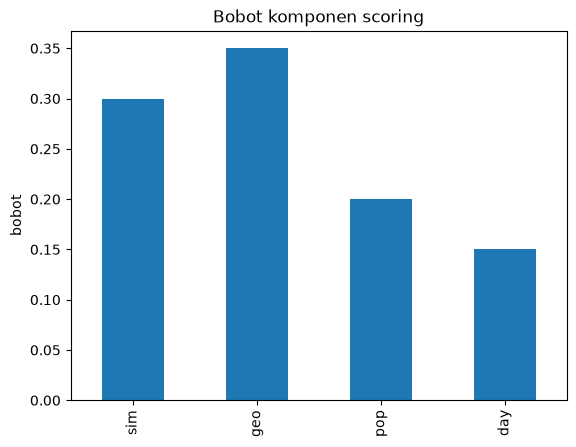

In [2]:
pd.Series(WEIGHTS).plot(kind="bar", title="Bobot komponen scoring")
plt.ylabel("bobot")
plt.show()

## Inisialisasi engine

In [3]:
rec = Recommender(csv_path="../../data/venues_enriched.csv")
print(f"Total venue ter-load: {len(rec.df)}")

Total venue ter-load: 6166


## Demo: turis di Monas, suka museum, kunjungan Sabtu

In [4]:
res = rec.recommend(lat=-6.1754, lon=106.8272,
                     category="tourism:museum", day="Sabtu", top_n=10)
res

,venue_id,name,venue_category,distance_km,jam_buka,unique_visitors,time_spent,References,score
109,way/199031142,Museum Taman Prasasti,tourism:museum,0.91,08:00 - 16:00,2311,98.4,https://en.wikipedia.org/wiki/Taman_Prasasti_M...,0.8240
84,way/121706048,Museum Tekstil,tourism:museum,2.39,09:00 - 15:00,3440,106.5,https://en.wikipedia.org/wiki/Textile_Museum_(...,0.8222
117,way/481759357,Museum Perumusan Naskah Proklamasi,tourism:museum,2.82,08:00 - 16:00,3122,82.0,https://en.wikipedia.org/wiki/Formulation_of_P...,0.8109
83,way/120553975,Museum Sumpah Pemuda,tourism:museum,1.99,09:00 - 16:00,2056,98.1,https://en.wikipedia.org/wiki/Youth_Pledge_Museum,0.8047
121,way/483343477,Museum Jenderal Besar Dr. A. H. Nasution,tourism:museum,2.04,08:00 - 16:00,2082,97.3,https://en.wikipedia.org/wiki/General_Abdul_Ha...,0.8044
122,way/485992342,Gedung Joang 45,tourism:museum,1.60,09:00 - 15:00,1390,100.3,https://id.wikipedia.org/wiki/Gedung_Joang_'45,0.7990
53,node/7117592125,Museum BNI,tourism:museum,4.54,09:00 - 16:00,3301,76.5,https://www.google.com/maps/search/?api=1&quer...,0.7898
110,way/199034576,Museum Kebangkitan Nasional,tourism:museum,1.25,08:00 - 16:00,508,107.3,https://id.wikipedia.org/wiki/Museum_Kebangkit...,0.7890
123,way/488380554,Museum Mohammad Hoesni Thamrin,tourism:museum,2.81,09:00 - 16:00,1727,85.0,https://www.google.com/maps/search/?api=1&quer...,0.7876
128,way/496544404,Taman Makam Tokoh Bangsa,tourism:museum,3.26,09:00 - 16:00,709,72.5,https://www.google.com/maps/search/?api=1&quer...,0.7643


## Demo: cold-start, tanpa preferensi kategori (netral)

In [5]:
res_netral = rec.recommend(lat=-6.1754, lon=106.8272, top_n=10)
res_netral

,venue_id,name,venue_category,distance_km,jam_buka,unique_visitors,time_spent,References,score
146,way/1472988297,King Chulalongkorn's Elephant statue,tourism:artwork,0.53,,7761,281.0,https://www.wikidata.org/wiki/Q137947145,0.6206
70,node/11296121151,Putri Duyung,tourism:artwork,6.14,,12063,232.0,https://www.google.com/maps/search/?api=1&quer...,0.6141
3512,way/485868913,Pasar Jati Rawasari,amenity:marketplace,4.12,,9569,67.3,https://www.google.com/maps/search/?api=1&quer...,0.6006
183,way/628537709,Taman Monas,tourism:yes,0.05,,5785,202.8,https://id.wikipedia.org/wiki/Medan_Merdeka,0.5942
3616,way/487637922,Pasar Mencos,amenity:marketplace,4.26,,9228,62.7,https://www.google.com/maps/search/?api=1&quer...,0.5929
3687,way/489687334,Pasar Impres Jembatan Besi,amenity:marketplace,4.32,,8068,69.3,https://www.google.com/maps/search/?api=1&quer...,0.5726
607,way/1159084257,Monumen Nasional,tourism:yes,0.00,,4424,230.8,https://id.wikipedia.org/wiki/Monumen_Nasional,0.5721
4026,way/495395310,Pasar Kota Bambu Selatan,amenity:marketplace,2.86,,6527,81.5,https://www.google.com/maps/search/?api=1&quer...,0.5673
143,way/748910286,Pembebasan Irian Jaya,tourism:artwork,1.02,,4812,273.6,https://id.wikipedia.org/wiki/Monumen_Pembebas...,0.5643
51,node/7076060048,Tugu Sepeda,tourism:artwork,3.80,,7102,240.6,https://www.google.com/maps/search/?api=1&quer...,0.5637


## Pengaruh jarak terhadap skor (sanity check komponen geo)

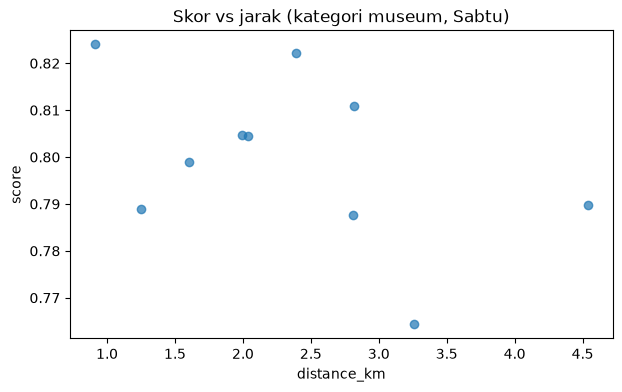

In [6]:
plt.figure(figsize=(7, 4))
plt.scatter(res["distance_km"], res["score"], alpha=0.7)
plt.xlabel("distance_km")
plt.ylabel("score")
plt.title("Skor vs jarak (kategori museum, Sabtu)")
plt.show()

## Eksperimen: ubah filter `only_open` (venue tutup di hari terpilih di-exclude)

In [7]:
res_open_only = rec.recommend(lat=-6.1754, lon=106.8272,
                               category="tourism:museum", day="Sabtu",
                               top_n=10, only_open=True)
print(f"Tanpa filter only_open: {len(res)} hasil")
print(f"Dengan filter only_open: {len(res_open_only)} hasil")

Tanpa filter only_open: 10 hasil
Dengan filter only_open: 10 hasil
